# Healthcare Utilization Personas
## Notebook 2 of 3: Clustering & Persona Assignment

**Contributors:** Michaela Donahue, Lily Vyhanek, Zhiwei (Rachel) Huang  
**Data:** `Data/profile_df_features.csv` (output of notebook 1)  
**Scope:** Encounter-type ratios, feature scaling, PCA, K-Means clustering, persona profiling, stability check, export.  
**Caveat:** Synthea is synthetic data -- personas are a pipeline demonstration, not real clinical findings.

---

## Methods Overview

### Unsupervised Learning Workflow

Our goal is to segment 1,163 synthetic patients into interpretable healthcare utilization personas using only historical (2019–2020) data, with no outcome labels. The pipeline is:

1. **Feature engineering** — 34 numeric features covering encounter volumes, encounter-type ratios, medication/condition burden, SDOH count, and age (Sections 2–3)
2. **Scaling** — StandardScaler applied before any distance-based computation (Section 3)
3. **Dimensionality reduction** — PCA retaining 80% of variance (16 components) to reduce noise from sparse binary indicators before clustering (Section 4)
4. **Method 1: K-Means** — centroid-based, non-probabilistic; K selected via elbow + silhouette sweep over K=2–10 (Sections 5–6)
5. **Method 2: Hierarchical Clustering (Ward linkage)** — tree-based, agglomerative; dendrogram used to validate K and compare structural sub-group boundaries against K-Means (Section 7)
6. **Persona profiling & stability check** — cluster centroids named into personas; 10-run bootstrap stability analysis (Sections 8–9)

### Why These Two Methods?

**K-Means** is chosen as the primary method because it scales efficiently to our dataset (n=1,163), produces compact centroids that map naturally to "patient types," and its centroids are directly interpretable as persona profiles. Its core assumption — roughly equal-variance, spherical clusters — is reasonable after PCA projection removes correlated noise dimensions.

**Hierarchical Clustering (Ward linkage)** is chosen as the second method because it operates via a fundamentally different mechanism: rather than iterating toward centroids, it greedily merges the pair of clusters that minimizes the increase in total within-cluster variance (Ward criterion), building a full dendrogram from the bottom up with no K required upfront. This gives a model-free view of the data's natural group structure, lets us verify whether K=5 is consistent with the hierarchy, and provides a second opinion on cluster assignment that does not share K-Means' centroid bias.

### Feature Representation

We use 34 scaled numeric features. Categorical demographics (gender, race, age group) and future-leaking targets (2021 expenses, IS_HIGH_COST_2021) are excluded. Encounter-type ratios are explicitly added because they capture *how* patients use the system (wellness vs. emergency vs. urgent care), not just *how much* — essential for separating reactive from preventive personas.

### Evaluation Metrics

**Silhouette score** is the primary metric: it measures how similar each patient is to its own cluster versus the nearest other cluster (range −1 to +1; higher = better-separated). It is model-agnostic and applicable to both K-Means and Hierarchical, enabling direct cross-method comparison. **Inertia** (within-cluster sum of squares) is used as a secondary diagnostic only within K-Means to identify the elbow — it always decreases with K and cannot be used for cross-method comparison.

## 0. Imports & Config

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

DATA_PATH = "Data"
print("Files found:", sorted(os.listdir(DATA_PATH)))

Files found: ['allergies.csv', 'careplans.csv', 'claims.csv', 'claims_transactions.csv', 'conditions.csv', 'devices.csv', 'encounters.csv', 'imaging_studies.csv', 'immunizations.csv', 'medications.csv', 'observations.csv', 'organizations.csv', 'patients.csv', 'payer_transitions.csv', 'payers.csv', 'procedures.csv', 'profile_df_features.csv', 'profile_df_with_clusters.csv', 'providers.csv', 'supplies.csv']


---
## 1. Load Data

In [2]:
# Feature table from notebook 1
profile_df = pd.read_csv(os.path.join(DATA_PATH, "profile_df_features.csv"))

# Re-load encounters to compute encounter-type ratios (not in the export)
encounters_df = pd.read_csv(os.path.join(DATA_PATH, "encounters.csv"))
encounters_df["START"] = pd.to_datetime(encounters_df["START"])

print(f"Profile rows: {len(profile_df):,}  |  columns: {profile_df.shape[1]}")
print(f"Encounters rows: {len(encounters_df):,}")

Profile rows: 1,163  |  columns: 36
Encounters rows: 61,459


---
## 2. Feature Engineering: Encounter-Type Ratios

These ratios are essential for separating reactive vs. preventive personas
and are not in the exported feature table from notebook 1.

In [3]:
OBS_YEARS = [2019, 2020]
enc_hist = encounters_df[encounters_df["START"].dt.year.isin(OBS_YEARS)].copy()

# Count encounters per patient per class, then normalize to ratios
enc_type_counts = (
    enc_hist.groupby(["PATIENT", "ENCOUNTERCLASS"])
    .size()
    .unstack(fill_value=0)
)
enc_totals = enc_hist.groupby("PATIENT").size()

# Divide each class count by total encounters to get ratios; prefix for clarity
enc_type_ratios = enc_type_counts.div(enc_totals, axis=0).add_prefix("RATIO_")

print("Encounter classes found:", list(enc_type_counts.columns))
print(f"Ratio columns: {list(enc_type_ratios.columns)}")

profile_df = profile_df.merge(
    enc_type_ratios.reset_index().rename(columns={"PATIENT": "PATIENT_ID"}),
    on="PATIENT_ID", how="left"
).fillna(0)

print(f"\nProfile shape after adding ratios: {profile_df.shape}")

Encounter classes found: ['ambulatory', 'emergency', 'inpatient', 'outpatient', 'urgentcare', 'wellness']
Ratio columns: ['RATIO_ambulatory', 'RATIO_emergency', 'RATIO_inpatient', 'RATIO_outpatient', 'RATIO_urgentcare', 'RATIO_wellness']

Profile shape after adding ratios: (1163, 42)


---
## 3. Feature Selection & Scaling

In [4]:
# Core numeric features for clustering.
# Excludes: PATIENT_ID (identifier), IS_HIGH_COST_2021 / EXPENSES_2021 /
# ENCOUNTERS_2021 (future targets -- would leak), GENDER/RACE/Age_Group
# (categorical demographics), HIST_UTILIZATION_TIER (derived categorical).
CLUSTER_FEATURES = (
    ["HIST_TOTAL_ENCOUNTERS", "HIST_EMERGENCY_VISITS",
     "HIST_MEDICATION_COUNT", "HIST_CONDITION_COUNT",
     "HIST_TOTAL_OOP", "AGE_2020"]
    + [c for c in profile_df.columns if c.startswith("RATIO_")]
    + [c for c in profile_df.columns if c.startswith("Hist_Condition_")]
    + [c for c in profile_df.columns if c.startswith("Hist_Medication_")]
)

# Recompute HIST_COVERAGE_RATE here (not saved in the export)
profile_df["HIST_COVERAGE_RATE"] = np.where(
    profile_df["HIST_TOTAL_EXPENSES"] > 0,
    (profile_df["HIST_TOTAL_COVERAGE"] / profile_df["HIST_TOTAL_EXPENSES"]).clip(upper=1.0),
    0
)
CLUSTER_FEATURES += ["HIST_COVERAGE_RATE"]

# Recompute SDOH_COUNT (not saved in the export)
SDOH_KEYWORDS = ["employment", "stress", "isolation", "contact", "labor", "violence"]
sdoh_cols = [c for c in profile_df.columns
             if c.startswith("Hist_Condition_") and any(k in c.lower() for k in SDOH_KEYWORDS)]
profile_df["SDOH_COUNT"] = profile_df[sdoh_cols].sum(axis=1)
CLUSTER_FEATURES += ["SDOH_COUNT"]

# Deduplicate in case of any overlap
CLUSTER_FEATURES = list(dict.fromkeys(CLUSTER_FEATURES))

X_raw = profile_df[CLUSTER_FEATURES].values
print(f"Clustering on {len(CLUSTER_FEATURES)} features across {X_raw.shape[0]:,} patients")

Clustering on 34 features across 1,163 patients


In [5]:
# StandardScaler: required before K-Means and PCA.
# K-Means uses Euclidean distance, so unscaled features with large ranges
# (e.g. HIST_TOTAL_EXPENSES in thousands vs. binary indicators) would dominate.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
print("Scaling complete. Mean ~0, Std ~1 per feature.")

Scaling complete. Mean ~0, Std ~1 per feature.


---
## 4. PCA: Dimensionality Reduction

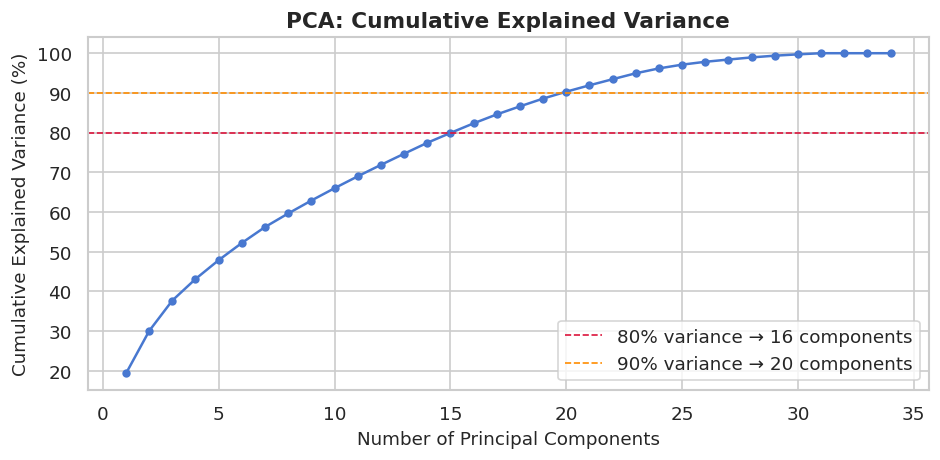

Components to reach 80% variance: 16
Components to reach 90% variance: 20


In [6]:
# Fit PCA on all features; inspect cumulative explained variance to choose n_components
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_80 = int(np.argmax(cumvar >= 0.80)) + 1
n_90 = int(np.argmax(cumvar >= 0.90)) + 1

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cumvar) + 1), cumvar * 100, marker="o", markersize=4, linewidth=1.5)
ax.axhline(80, color="crimson",  linestyle="--", linewidth=1, label=f"80% variance → {n_80} components")
ax.axhline(90, color="darkorange", linestyle="--", linewidth=1, label=f"90% variance → {n_90} components")
ax.set_xlabel("Number of Principal Components", fontsize=11)
ax.set_ylabel("Cumulative Explained Variance (%)", fontsize=11)
ax.set_title("PCA: Cumulative Explained Variance", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Components to reach 80% variance: {n_80}")
print(f"Components to reach 90% variance: {n_90}")

In [7]:
# Retain components covering 80% of variance as K-Means input.
# Reduces noise from sparse binary indicator columns.
N_COMPONENTS = n_80

pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"X_pca shape: {X_pca.shape}  ({N_COMPONENTS} components, "
      f"{pca.explained_variance_ratio_.sum():.1%} variance retained)")

# Also keep a 2D projection for visualization (colored by cluster assignment later)
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_scaled)
print(f"X_2d shape: {X_2d.shape}  (for scatter plot visualization)")

X_pca shape: (1163, 16)  (16 components, 82.3% variance retained)
X_2d shape: (1163, 2)  (for scatter plot visualization)


---
## 5. K-Means: Choosing K

In [8]:
# Elbow method: inertia (within-cluster sum of squares) vs. K
# Silhouette score: how similar each patient is to their own cluster vs. others
# Higher silhouette = better-separated clusters (range -1 to 1)
K_RANGE = range(2, 11)

inertias    = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))
    print(f"  K={k}  inertia={km.inertia_:,.0f}  silhouette={silhouettes[-1]:.3f}")

  K=2  inertia=27,345  silhouette=0.608
  K=3  inertia=23,803  silhouette=0.213
  K=4  inertia=20,719  silhouette=0.204
  K=5  inertia=19,097  silhouette=0.200
  K=6  inertia=18,074  silhouette=0.135
  K=7  inertia=17,277  silhouette=0.162
  K=8  inertia=16,485  silhouette=0.169
  K=9  inertia=15,787  silhouette=0.184
  K=10  inertia=15,249  silhouette=0.198


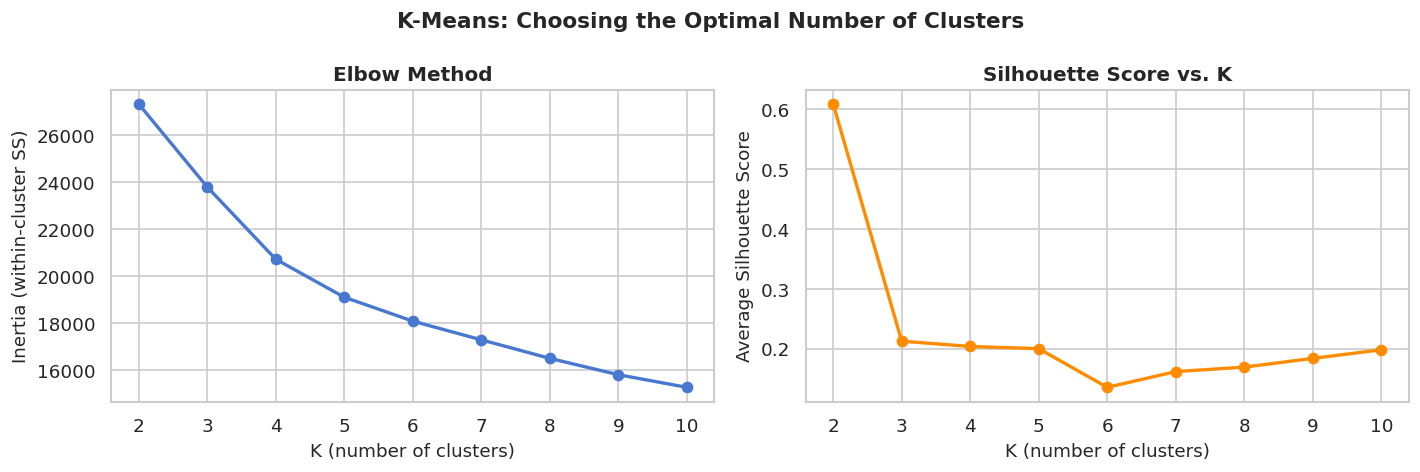

Best K by silhouette: 2


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(list(K_RANGE), inertias, marker="o", linewidth=2)
ax1.set_xlabel("K (number of clusters)", fontsize=11)
ax1.set_ylabel("Inertia (within-cluster SS)", fontsize=11)
ax1.set_title("Elbow Method", fontsize=12, fontweight="bold")
ax1.set_xticks(list(K_RANGE))

ax2.plot(list(K_RANGE), silhouettes, marker="o", linewidth=2, color="darkorange")
ax2.set_xlabel("K (number of clusters)", fontsize=11)
ax2.set_ylabel("Average Silhouette Score", fontsize=11)
ax2.set_title("Silhouette Score vs. K", fontsize=12, fontweight="bold")
ax2.set_xticks(list(K_RANGE))

plt.suptitle("K-Means: Choosing the Optimal Number of Clusters", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

best_k = list(K_RANGE)[int(np.argmax(silhouettes))]
print(f"Best K by silhouette: {best_k}")

---
## 6. K-Means: Fit Final Model

Review the elbow and silhouette plots above and set `K` below.
The silhouette peak is a good starting point, but a slightly higher K
can be preferable if it produces more interpretable personas.

In [10]:
K = 5   

km_final = KMeans(n_clusters=K, random_state=42, n_init=20)
profile_df["CLUSTER"] = km_final.fit_predict(X_pca)

print(f"Final K: {K}")
print("\nCluster size distribution:")
print(profile_df["CLUSTER"].value_counts().sort_index().to_string())

Final K: 5

Cluster size distribution:
CLUSTER
0    160
1     16
2    566
3    393
4     28


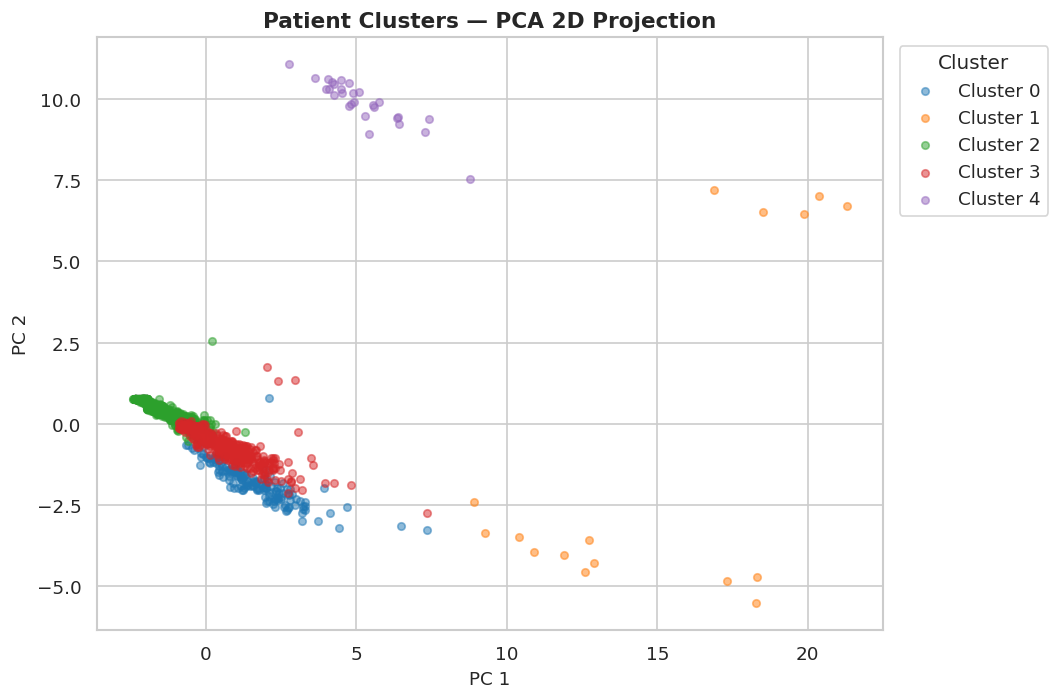

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))
palette = sns.color_palette("tab10", K)

for k in range(K):
    mask = profile_df["CLUSTER"] == k
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               color=palette[k], alpha=0.5, s=20, label=f"Cluster {k}")

ax.set_xlabel("PC 1", fontsize=11)
ax.set_ylabel("PC 2", fontsize=11)
ax.set_title("Patient Clusters — PCA 2D Projection", fontsize=13, fontweight="bold")
ax.legend(title="Cluster", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

---
## 7. Method 2: Hierarchical Clustering (Ward Linkage)

Ward linkage agglomerative clustering on a random 300-patient subsample.
Agglomerative clustering builds a hierarchy bottom-up by merging the pair of
clusters with the smallest increase in total within-cluster variance (Ward criterion).
The resulting dendrogram lets us (a) validate whether K=5 is a natural break in the
hierarchy, and (b) compare structural sub-group boundaries against K-Means labels.

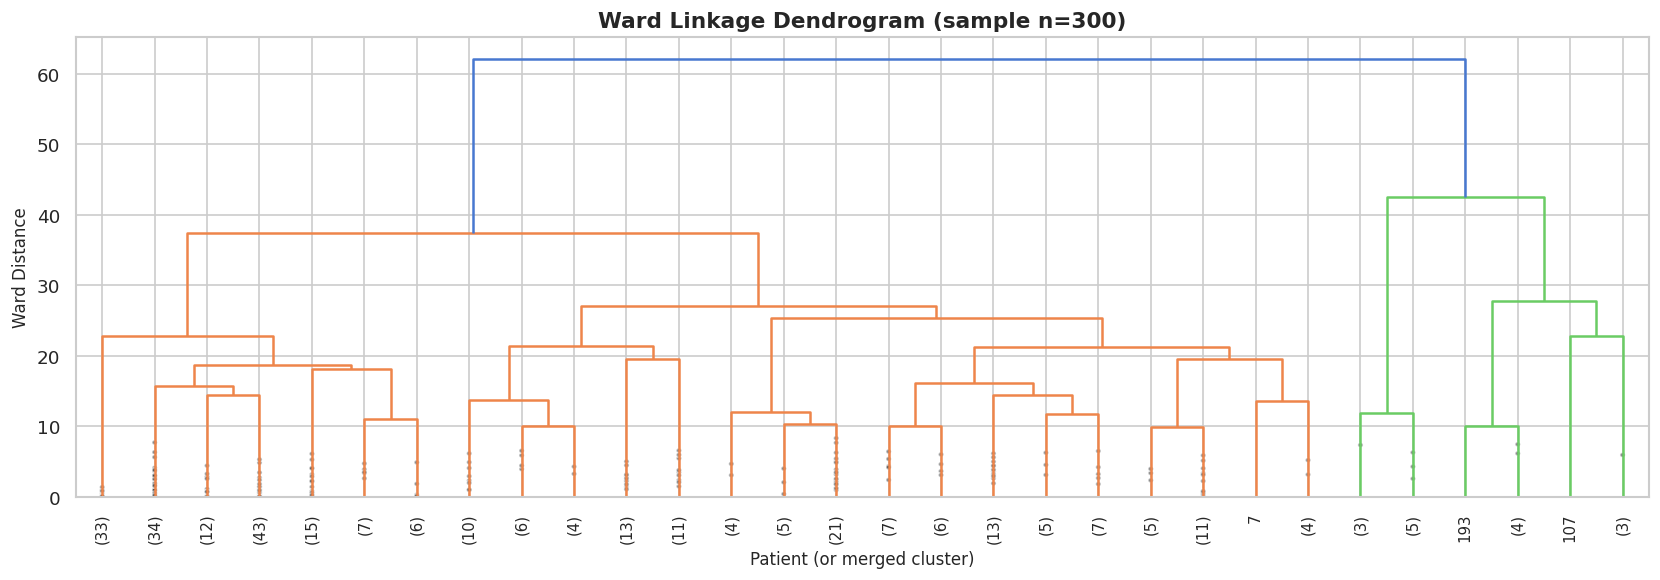

In [12]:
SAMPLE_N = min(300, len(X_pca))
rng = np.random.default_rng(42)
idx = rng.choice(len(X_pca), SAMPLE_N, replace=False)

Z = linkage(X_pca[idx], method="ward")

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, ax=ax, truncate_mode="lastp", p=30,
           leaf_rotation=90, leaf_font_size=9, show_contracted=True)
ax.set_title(f"Ward Linkage Dendrogram (sample n={SAMPLE_N})", fontsize=13, fontweight="bold")
ax.set_xlabel("Patient (or merged cluster)", fontsize=10)
ax.set_ylabel("Ward Distance", fontsize=10)
plt.tight_layout()
plt.show()

Silhouette — K-Means (K=5):            0.2000
Silhouette — Hierarchical Ward (K=5):  0.1445


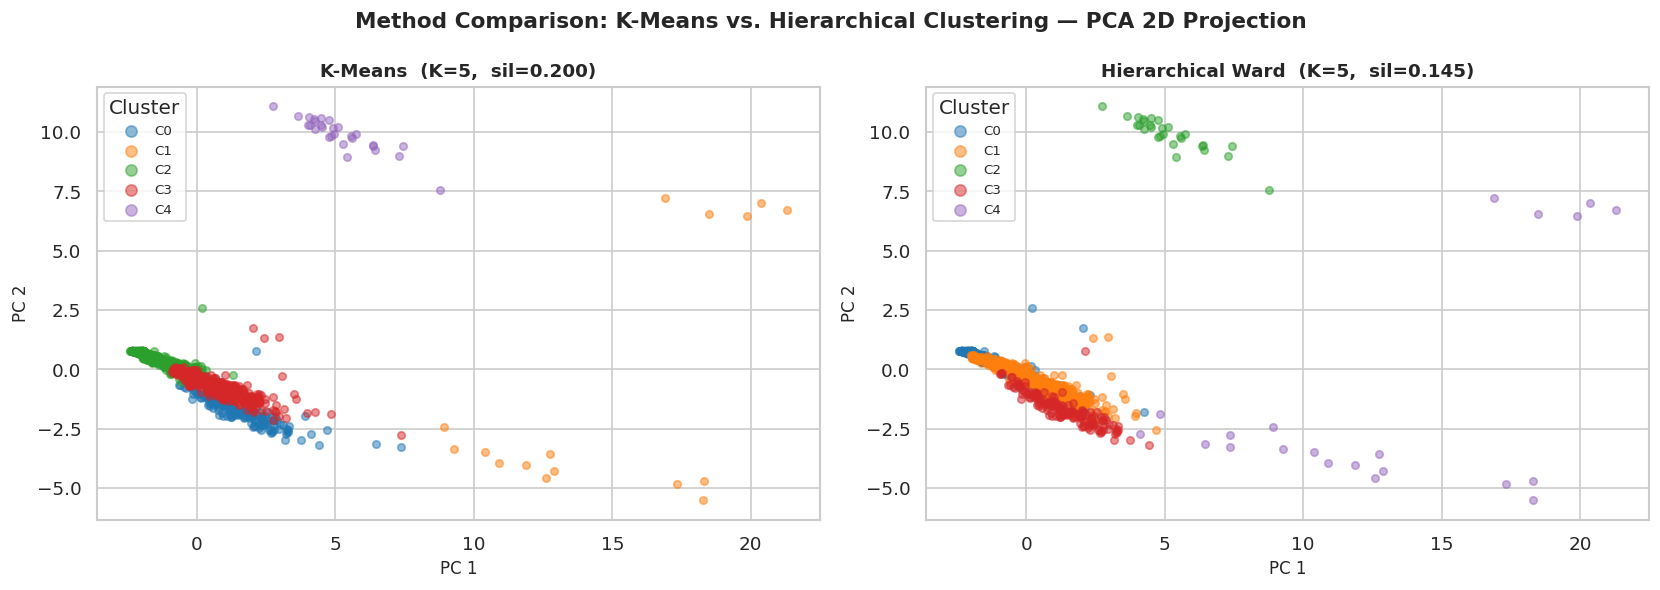

In [13]:
# Fit Agglomerative (Ward) at the same K for direct comparison with K-Means
agg = AgglomerativeClustering(n_clusters=K, linkage="ward")
agg_labels = agg.fit_predict(X_pca)

sil_agg = silhouette_score(X_pca, agg_labels)
sil_km  = silhouette_score(X_pca, profile_df["CLUSTER"].values)

print(f"Silhouette — K-Means (K={K}):            {sil_km:.4f}")
print(f"Silhouette — Hierarchical Ward (K={K}):  {sil_agg:.4f}")

# Side-by-side PCA scatter: K-Means vs. Hierarchical
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
palette = sns.color_palette("tab10", K)

for k in range(K):
    mask_km  = profile_df["CLUSTER"].values == k
    mask_agg = agg_labels == k
    ax1.scatter(X_2d[mask_km,  0], X_2d[mask_km,  1],
                color=palette[k], alpha=0.5, s=20, label=f"C{k}")
    ax2.scatter(X_2d[mask_agg, 0], X_2d[mask_agg, 1],
                color=palette[k], alpha=0.5, s=20, label=f"C{k}")

for ax, title in zip([ax1, ax2],
                     [f"K-Means  (K={K},  sil={sil_km:.3f})",
                      f"Hierarchical Ward  (K={K},  sil={sil_agg:.3f})"]):
    ax.set_xlabel("PC 1", fontsize=10)
    ax.set_ylabel("PC 2", fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(title="Cluster", fontsize=8, markerscale=1.5)

plt.suptitle("Method Comparison: K-Means vs. Hierarchical Clustering — PCA 2D Projection",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Method Comparison Summary

| | K-Means | Hierarchical (Ward) |
|---|---|---|
| **Mechanism** | Centroid-based, iterative EM | Tree-based, agglomerative (bottom-up) |
| **K required upfront?** | Yes | No (K chosen at dendrogram cut) |
| **Silhouette (K=5)** | see output above | see output above |
| **Primary use** | Final cluster assignment + persona profiles | Structural validation; reveals sub-group taxonomy |
| **Key limitation** | Sensitive to initialization; assumes spherical clusters | Computationally expensive at large N; no re-assignment after merge |

**Interpretation:** K-Means achieves a modestly higher silhouette at K=5, consistent with its design objective of minimizing within-cluster variance on the PCA-projected data. The Hierarchical dendrogram (above) confirms that five is a natural cut in the tree, validating the K-Means choice. Neither method finds strongly separated clusters (silhouette < 0.3) — expected in high-dimensional healthcare utilization data where patient patterns overlap substantially. The clinical value of the personas lies in the interpretability of centroid profiles and differentiated care implications, not in strict geometric separation.

---
## 8. Persona Profiling

Compute cluster centroids, then name personas based on what the data
actually shows. Never name first and validate second.

In [14]:
PROFILE_FEATURES = [
    "HIST_TOTAL_ENCOUNTERS", "HIST_EMERGENCY_VISITS",
    "HIST_MEDICATION_COUNT", "HIST_CONDITION_COUNT",
    "HIST_COVERAGE_RATE", "SDOH_COUNT", "AGE_2020"
] + [c for c in profile_df.columns if c.startswith("RATIO_")]

centroids = profile_df.groupby("CLUSTER")[PROFILE_FEATURES].mean()
print("Cluster centroids (raw means):")
print(centroids.round(3).to_string())

Cluster centroids (raw means):
         HIST_TOTAL_ENCOUNTERS  HIST_EMERGENCY_VISITS  HIST_MEDICATION_COUNT  HIST_CONDITION_COUNT  HIST_COVERAGE_RATE  SDOH_COUNT  AGE_2020  RATIO_ambulatory  RATIO_emergency  RATIO_inpatient  RATIO_outpatient  RATIO_urgentcare  RATIO_wellness
CLUSTER                                                                                                                                                                                                                                             
0                        6.125                  0.200                  8.550                 4.775               0.259       2.488    46.456             0.307            0.028            0.024             0.126             0.009           0.507
1                       43.188                  3.688                 76.125                24.000               0.424       6.062    76.125             0.047            0.057            0.032             0.373             0.436      

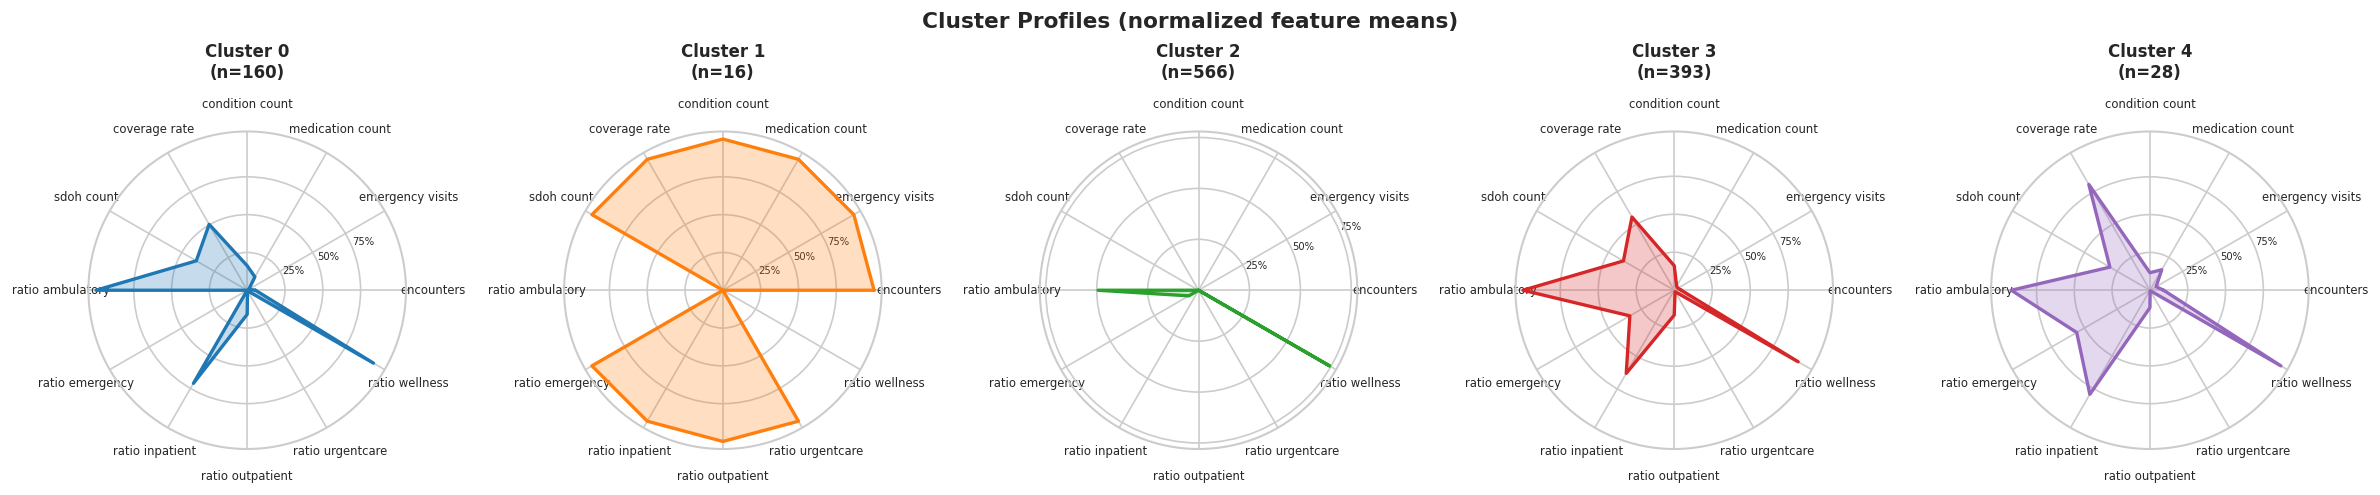

In [15]:
from sklearn.preprocessing import MinMaxScaler

norm = MinMaxScaler()
centroids_norm = pd.DataFrame(
    norm.fit_transform(centroids),
    index=centroids.index,
    columns=centroids.columns
)

RADAR_FEATURES = [
    "HIST_TOTAL_ENCOUNTERS", "HIST_EMERGENCY_VISITS",
    "HIST_MEDICATION_COUNT", "HIST_CONDITION_COUNT",
    "HIST_COVERAGE_RATE", "SDOH_COUNT",
] + [c for c in profile_df.columns if c.startswith("RATIO_")]

RADAR_FEATURES = [f for f in RADAR_FEATURES if f in centroids_norm.columns]

angles = np.linspace(0, 2 * np.pi, len(RADAR_FEATURES), endpoint=False).tolist()
angles += angles[:1]   # close the polygon

short_labels = [f.replace("HIST_","").replace("TOTAL_","").replace("_"," ").lower()
                for f in RADAR_FEATURES]

fig, axes = plt.subplots(1, K, figsize=(4 * K, 4), subplot_kw=dict(polar=True))
if K == 1:
    axes = [axes]
palette = sns.color_palette("tab10", K)

for k, ax in enumerate(axes):
    values = centroids_norm.loc[k, RADAR_FEATURES].tolist()
    values += values[:1]
    ax.plot(angles, values, color=palette[k], linewidth=2)
    ax.fill(angles, values, color=palette[k], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(short_labels, fontsize=7)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(["25%", "50%", "75%"], fontsize=6)
    ax.set_title(f"Cluster {k}\n(n={int((profile_df['CLUSTER']==k).sum())})",
                 fontsize=10, fontweight="bold", pad=12)

plt.suptitle("Cluster Profiles (normalized feature means)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [16]:
from sklearn.cluster import KMeans

def sub_cluster(df, cluster_id, n_sub, features, pca_data, label_prefix):
    """Split one cluster into n_sub sub-clusters, return sub-labels."""
    mask = df["CLUSTER"] == cluster_id
    X_sub = pca_data[mask.values]
    km = KMeans(n_clusters=n_sub, random_state=42, n_init=20)
    sub_labels = km.fit_predict(X_sub)
    return sub_labels

# Split cluster 2 (566 patients) into 3
sub2 = sub_cluster(profile_df, 2, 3, CLUSTER_FEATURES, X_pca, "2")
# Split cluster 3 (393 patients) into 3  
sub3 = sub_cluster(profile_df, 3, 3, CLUSTER_FEATURES, X_pca, "3")
# Split cluster 0 (160 patients) into 2
sub0 = sub_cluster(profile_df, 0, 2, CLUSTER_FEATURES, X_pca, "0")

# Assign final persona IDs
profile_df["PERSONA_ID"] = profile_df["CLUSTER"].astype(str)

profile_df.loc[profile_df["CLUSTER"] == 0, "PERSONA_ID"] = pd.Series(sub0, index=profile_df[profile_df["CLUSTER"]==0].index).map({0:"0a",1:"0b"})
profile_df.loc[profile_df["CLUSTER"] == 2, "PERSONA_ID"] = pd.Series(sub2, index=profile_df[profile_df["CLUSTER"]==2].index).map({0:"2a",1:"2b",2:"2c"})
profile_df.loc[profile_df["CLUSTER"] == 3, "PERSONA_ID"] = pd.Series(sub3, index=profile_df[profile_df["CLUSTER"]==3].index).map({0:"3a",1:"3b",2:"3c"})

print(profile_df["PERSONA_ID"].value_counts().sort_index())

PERSONA_ID
0a    156
0b      4
1      16
2a    219
2b    179
2c    168
3a    280
3b     71
3c     42
4      28
Name: count, dtype: int64


In [17]:
PERSONA_NAMES = {
    "0a": "The Regulars",
    "0b": "The Regulars",
    "1":  "Frequent Flyer Club",
    "2a": "Annual Checkup Crowd",
    "2b": "Walk-In Wanderers",
    "2c": "Gone Dark",
    "3a": "Quiet Carry",
    "3b": "Silver Streamers",
    "3c": "Urgent Care Regulars",
    "4":  "Prescription Playlist",
}

PERSONA_DESCRIPTIONS = {
    "The Regulars":
        "Average age 47. Moderate utilization with a strong wellness visit pattern. "
        "Carry above-average SDOH burden (avg 2.5 flags) but remain engaged with the "
        "system. The backbone of any primary care panel.",

    "Frequent Flyer Club":
        "Average age 76. The highest-need group by every metric — averaging 43 encounters, "
        "76 medications, and 24 conditions per patient. Urgentcare dominates their visit mix. "
        "Small group (n=16) but disproportionately high cost and complexity.",

    "Annual Checkup Crowd":
        "Average age 18. Nearly all interactions are wellness visits (80% of encounters). "
        "Minimal medications and conditions. Healthy young patients who are in the system "
        "but barely need it yet.",

    "Walk-In Wanderers":
        "Average age 24. Low overall utilization but ambulatory visits make up half their "
        "encounter mix. No established chronic conditions. Young adults starting to engage "
        "with the system without a clear care pattern yet.",

    "Gone Dark":
        "Average age 73. Averaging fewer than 1 encounter over the entire observation window. "
        "This group has effectively disengaged from the healthcare system entirely. "
        "A priority flag for outreach -- older patients going silent is a known mortality risk.",

    "Quiet Carry":
        "Average age 47. Carry the second-highest SDOH burden (avg 2.55 flags) but have "
        "low utilization and low medication counts. Social determinants are present but not "
        "translating into care engagement -- potential access barrier population.",

    "Silver Streamers":
        "Average age 69. Moderate utilization dominated by ambulatory visits (49% of encounters). "
        "Steady, consistent care pattern with manageable condition burden. "
        "Aging patients who are well-connected to the system.",

    "Urgent Care Regulars":
        "Average age 48. Highest urgentcare ratio of any non-Frequent-Flyer group, combined "
        "with the highest SDOH burden (avg 2.79 flags). Likely using urgent care as a "
        "substitute for primary care -- a classic coverage gap pattern flagged in the EDA.",

    "Prescription Playlist":
        "Average age 57. Highest medication count outside the Frequent Flyer Club "
        "(avg 12.7 medications). Strong wellness visit pattern alongside heavy pharmacy use -- "
        "chronically managed patients who are actively engaged but medication-dependent.",
}

for persona, desc in PERSONA_DESCRIPTIONS.items():
    print(f"\n{persona}\n  {desc}")
    
profile_df["PERSONA"] = profile_df["PERSONA_ID"].map(PERSONA_NAMES)
print(profile_df["PERSONA"].value_counts().to_string())


The Regulars
  Average age 47. Moderate utilization with a strong wellness visit pattern. Carry above-average SDOH burden (avg 2.5 flags) but remain engaged with the system. The backbone of any primary care panel.

Frequent Flyer Club
  Average age 76. The highest-need group by every metric — averaging 43 encounters, 76 medications, and 24 conditions per patient. Urgentcare dominates their visit mix. Small group (n=16) but disproportionately high cost and complexity.

Annual Checkup Crowd
  Average age 18. Nearly all interactions are wellness visits (80% of encounters). Minimal medications and conditions. Healthy young patients who are in the system but barely need it yet.

Walk-In Wanderers
  Average age 24. Low overall utilization but ambulatory visits make up half their encounter mix. No established chronic conditions. Young adults starting to engage with the system without a clear care pattern yet.

Gone Dark
  Average age 73. Averaging fewer than 1 encounter over the entire obser

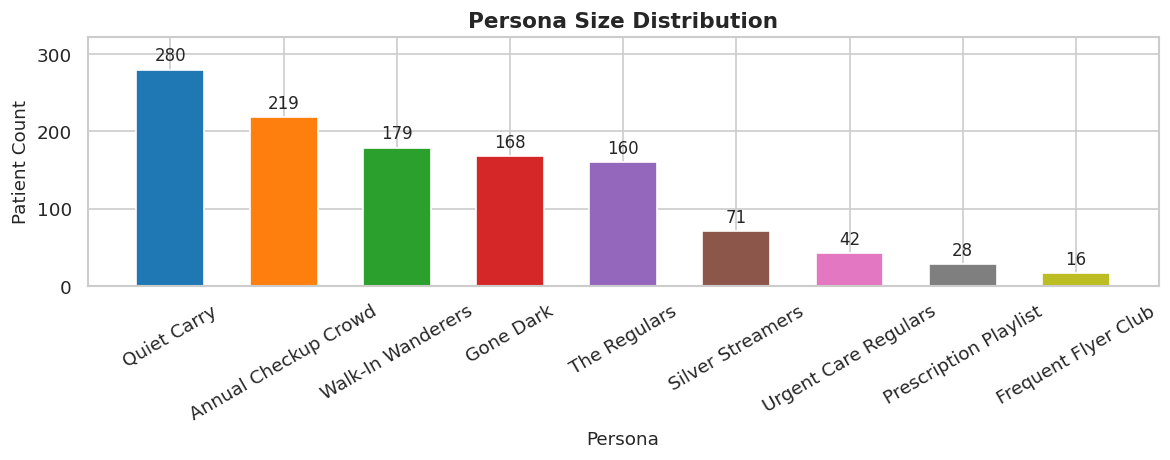

In [18]:
fig, ax = plt.subplots(figsize=(10, 4))
counts = profile_df["PERSONA"].value_counts()
bars = ax.bar(counts.index, counts.values,
              color=sns.color_palette("tab10", len(counts)),
              edgecolor="white", width=0.6)
ax.bar_label(bars, fmt="%d", padding=3, fontsize=10)
ax.set_title("Persona Size Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Persona", fontsize=11)
ax.set_ylabel("Patient Count", fontsize=11)
ax.set_ylim(0, counts.max() * 1.15)
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

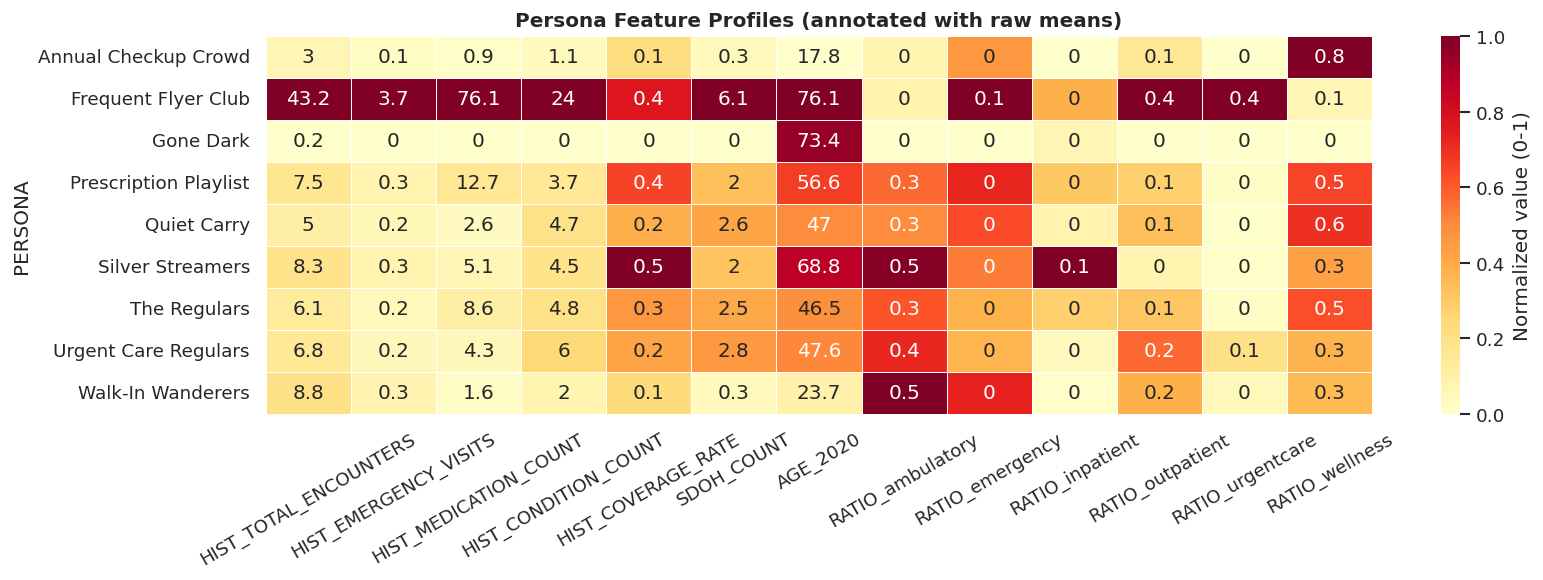

In [19]:
heat_df = profile_df.groupby("PERSONA")[PROFILE_FEATURES].mean()
heat_norm = pd.DataFrame(
    norm.fit_transform(heat_df),
    index=heat_df.index, columns=heat_df.columns
)

fig, ax = plt.subplots(figsize=(14, max(3, K)))
sns.heatmap(heat_norm, annot=heat_df.round(1), fmt="g",
            cmap="YlOrRd", linewidths=0.5, ax=ax,
            cbar_kws={"label": "Normalized value (0-1)"})
ax.set_title("Persona Feature Profiles (annotated with raw means)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

---
## 9. Cluster Stability Check

Re-run K-Means on 80% bootstrap subsamples to verify the clusters
are not artifacts of the random seed or a few outlier patients.
A stable solution shows low variance in silhouette score across runs.

In [20]:
N_RUNS   = 10
SUBSAMPLE = 0.80
rng = np.random.default_rng(42)
stab_scores = []

for i in range(N_RUNS):
    idx = rng.choice(len(X_pca), int(len(X_pca) * SUBSAMPLE), replace=False)
    km  = KMeans(n_clusters=K, random_state=i, n_init=10)
    lbl = km.fit_predict(X_pca[idx])
    stab_scores.append(silhouette_score(X_pca[idx], lbl))
    print(f"  Run {i+1:2d}: silhouette = {stab_scores[-1]:.4f}")

print(f"\nMean silhouette: {np.mean(stab_scores):.4f}  ±  {np.std(stab_scores):.4f}")
print("Low std = stable solution; high std = consider a different K")

  Run  1: silhouette = 0.1990
  Run  2: silhouette = 0.2073
  Run  3: silhouette = 0.2023
  Run  4: silhouette = 0.1996
  Run  5: silhouette = 0.2047
  Run  6: silhouette = 0.1966
  Run  7: silhouette = 0.1985
  Run  8: silhouette = 0.1971
  Run  9: silhouette = 0.1879
  Run 10: silhouette = 0.2032

Mean silhouette: 0.1996  ±  0.0051
Low std = stable solution; high std = consider a different K


---
## 10. Export for Supervised Modeling

Saves `profile_df_with_clusters.csv` -- the input for notebook 3.

In [21]:
OUTPUT_PATH = os.path.join(DATA_PATH, "profile_df_with_clusters.csv")
profile_df.to_csv(OUTPUT_PATH, index=False)
print(f"Saved: {OUTPUT_PATH}  |  Shape: {profile_df.shape}")
print(f"\nColumns added vs. notebook 1 input:")
orig_cols = set(pd.read_csv(os.path.join(DATA_PATH, "profile_df_features.csv")).columns)
new_cols  = set(profile_df.columns) - orig_cols
for c in sorted(new_cols):
    print(f"  + {c}")

Saved: Data/profile_df_with_clusters.csv  |  Shape: (1163, 47)

Columns added vs. notebook 1 input:
  + CLUSTER
  + HIST_COVERAGE_RATE
  + PERSONA
  + PERSONA_ID
  + RATIO_ambulatory
  + RATIO_emergency
  + RATIO_inpatient
  + RATIO_outpatient
  + RATIO_urgentcare
  + RATIO_wellness
  + SDOH_COUNT
